# Week 3 — Segmentation

Digital Image Processing mini project: Driver Drowsiness Detection.
Amey Pawar (23108B0057), Sejal Andhale (23108B0049).

Isolates the dark iris/pupil region on Week-2-enhanced (64x64, CLAHE+gamma+glare-suppressed)
eye crops, via:

1. Global **Otsu** thresholding and local **adaptive** thresholding (mean & Gaussian variants) —
   compared quantitatively over the full 6000-image working set, not just eyeballed.
2. **Region isolation**: the pupil/iris is the darkest structure in these near-IR crops; a
   stricter, Otsu-anchored threshold isolates its darker core, then the largest connected
   component (above a minimum-area gate) is kept as the candidate. Closed eyes, honestly, often
   fail this gate — an empty/degenerate mask is the expected, correct output, not a bug.

All segmentation logic lives in `src/segment.py` (not duplicated here); this notebook calls it
and visualizes/measures its behaviour.

In [1]:
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "src").is_dir() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from src.dataset import load_manifest
from src.preprocess import PreprocessConfig, preprocess_pipeline
from src.segment import (
    SegmentConfig,
    adaptive_threshold,
    compare_methods_on_image,
    isolate_dark_region,
    otsu_threshold,
    segment_eye,
)

RESULTS_DIR = REPO_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

cfg_pre = PreprocessConfig()
samples = load_manifest(REPO_ROOT / "data" / "samples" / "manifest.csv")
print(f"{len(samples)} curated samples loaded")

def load_enhanced(sample):
    raw = cv2.imread(str(sample.path), cv2.IMREAD_GRAYSCALE)
    return preprocess_pipeline(raw, cfg_pre)


40 curated samples loaded


## 1. Otsu vs. adaptive thresholding — side by side, open and closed eye

Dark-foreground convention throughout: white (255) in every mask below marks pixels *darker*
than the chosen threshold (iris/pupil candidate), not the sclera.

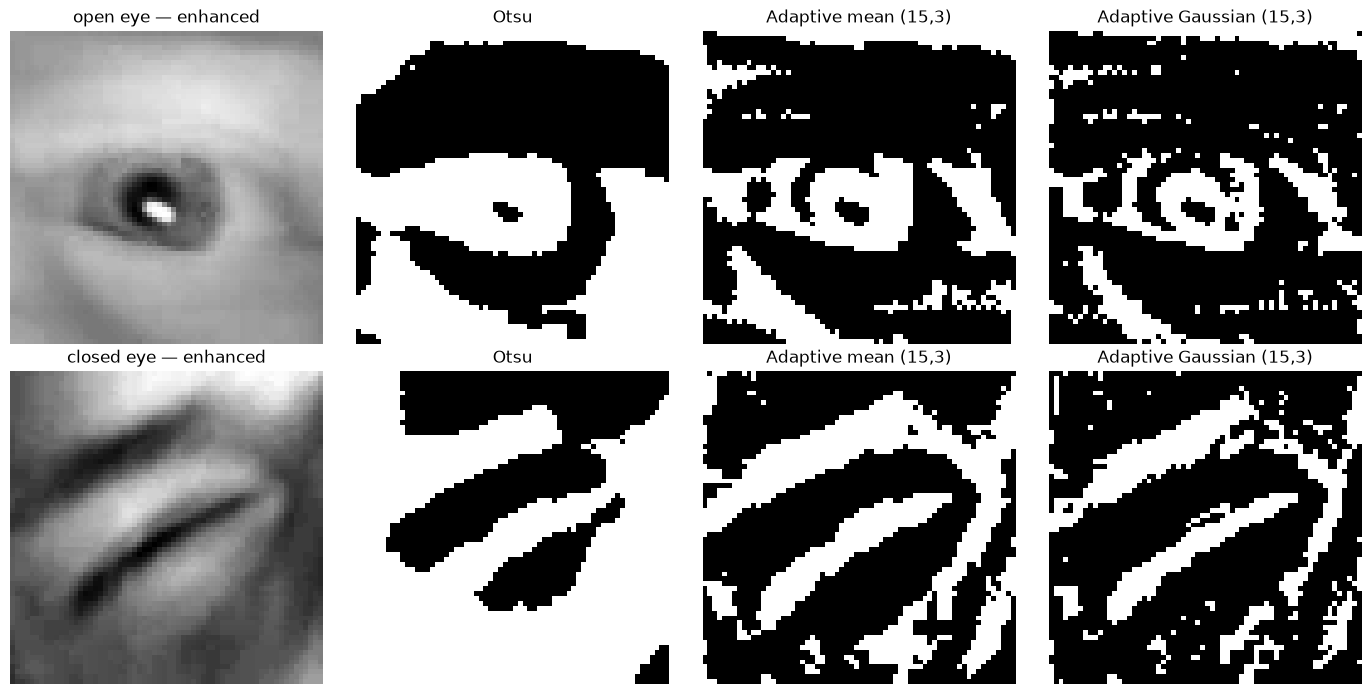

In [2]:
open_sample = next(s for s in samples if s.is_open)
closed_sample = next(s for s in samples if not s.is_open)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for row, sample, label in [(0, open_sample, "open"), (1, closed_sample, "closed")]:
    img = load_enhanced(sample)
    _, otsu_mask = otsu_threshold(img)
    mean_mask = adaptive_threshold(img, "mean", block_size=15, C=3)
    gauss_mask = adaptive_threshold(img, "gaussian", block_size=15, C=3)

    axes[row, 0].imshow(img, cmap="gray"); axes[row, 0].set_title(f"{label} eye — enhanced")
    axes[row, 1].imshow(otsu_mask, cmap="gray"); axes[row, 1].set_title("Otsu")
    axes[row, 2].imshow(mean_mask, cmap="gray"); axes[row, 2].set_title("Adaptive mean (15,3)")
    axes[row, 3].imshow(gauss_mask, cmap="gray"); axes[row, 3].set_title("Adaptive Gaussian (15,3)")
    for ax in axes[row]:
        ax.axis("off")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "week3_otsu_vs_adaptive.png", dpi=120)
plt.show()

Visually, the adaptive masks are already noticeably speckled — each small local
neighbourhood in a CLAHE-flattened 64x64 crop chases its own noise, producing many tiny
components instead of one clean dark blob. The quantitative comparison below confirms this is
not a one-image fluke.

## 2. Histogram with the Otsu threshold marked

Classic DIP evidence: Otsu picks the threshold that minimizes intra-class variance across the
*whole* image histogram. Marking it on the histogram shows what Otsu is actually doing to this
data.

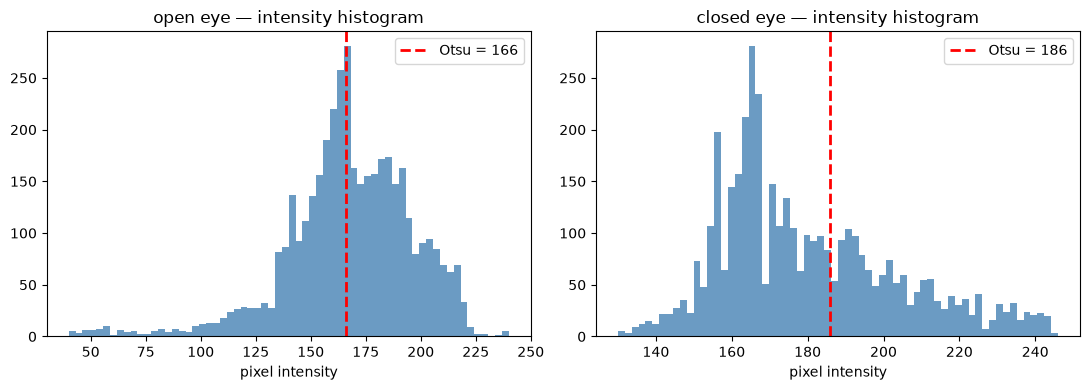

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, sample, label in [(axes[0], open_sample, "open"), (axes[1], closed_sample, "closed")]:
    img = load_enhanced(sample)
    thresh_val, _ = otsu_threshold(img)
    ax.hist(img.ravel(), bins=64, color="steelblue", alpha=0.8)
    ax.axvline(thresh_val, color="red", linestyle="--", linewidth=2, label=f"Otsu = {thresh_val:.0f}")
    ax.set_title(f"{label} eye — intensity histogram")
    ax.set_xlabel("pixel intensity")
    ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "week3_otsu_histogram.png", dpi=120)
plt.show()

Note the Otsu threshold lands close to the histogram's *median*, not at a sharp bimodal
valley — CLAHE (Week 2) has already flattened local contrast toward a roughly uniform
distribution, so the "natural" iris/sclera valley Otsu is designed to find is largely gone by
the time it runs. This is measured explicitly in Section 3, not just implied by two example
histograms.

## 3. Quantitative comparison — Otsu vs. adaptive mean vs. adaptive Gaussian

Run over **all 6000** working-set images (not sampled): number of connected components per
mask (fragmentation/speckle proxy — fewer, larger components means a cleaner starting mask for
Week 4's morphology to refine), mean dark-area fraction, and per-image timing.

In [4]:
import csv
import time

working_set = list(csv.DictReader(open(REPO_ROOT / "data" / "working_set.csv")))
print(f"{len(working_set)} rows in working set")

t0 = time.perf_counter()
enhanced_imgs = []
for row in working_set:
    raw = cv2.imread(str(REPO_ROOT / row["source_relpath"]), cv2.IMREAD_GRAYSCALE)
    enhanced_imgs.append(preprocess_pipeline(raw, cfg_pre))
print(f"preprocessed {len(enhanced_imgs)} images in {time.perf_counter() - t0:.2f}s")

6000 rows in working set


preprocessed 6000 images in 1.98s


In [5]:
def n_components(mask):
    return cv2.connectedComponentsWithStats(mask, connectivity=8)[0] - 1

methods = {
    "otsu": lambda im: otsu_threshold(im)[1],
    "adaptive_mean (block=15, C=3)": lambda im: adaptive_threshold(im, "mean", 15, 3),
    "adaptive_gaussian (block=15, C=3)": lambda im: adaptive_threshold(im, "gaussian", 15, 3),
}

print(f"{'method':<34}{'mean n_comp':>12}{'median n_comp':>14}{'mean area frac':>16}{'us/image':>10}")
comparison_rows = []
for name, fn in methods.items():
    t0 = time.perf_counter()
    ncomps, areas = [], []
    for im in enhanced_imgs:
        m = fn(im)
        ncomps.append(n_components(m))
        areas.append((m.sum() / 255) / (64 * 64))
    elapsed = time.perf_counter() - t0
    mean_nc = sum(ncomps) / len(ncomps)
    median_nc = sorted(ncomps)[len(ncomps) // 2]
    mean_area = sum(areas) / len(areas)
    us_per_img = elapsed / len(enhanced_imgs) * 1e6
    comparison_rows.append((name, mean_nc, median_nc, mean_area, us_per_img))
    print(f"{name:<34}{mean_nc:>12.2f}{median_nc:>14}{mean_area:>16.4f}{us_per_img:>10.1f}")

method                             mean n_comp median n_comp  mean area frac  us/image


otsu                                      5.82             4          0.4993     101.4


adaptive_mean (block=15, C=3)            28.07            23          0.3573     126.1


adaptive_gaussian (block=15, C=3)        61.87            55          0.2920     177.6


**Otsu wins decisively on fragmentation**: ~5.8 mean connected components vs. ~28 (adaptive
mean) and ~62 (adaptive Gaussian) — roughly 5x and 11x more speckle respectively, at
comparable or slower per-image cost. Adaptive thresholding's local neighbourhood statistic
reacts to CLAHE-amplified local texture/noise inside what should be one smooth region, exactly
because CLAHE has already equalized local contrast (Week 2) — the two techniques fight each
other on this pipeline. **Otsu (global) is chosen as the default segmentation method** for this
dataset: far fewer components means far less work for Week 4's morphological cleanup, and a
global threshold is defensible here specifically because CLAHE already normalized local
contrast, so a single global split is meaningful across the whole crop.

## 4. Region isolation and the closed-eye degenerate case

A plain Otsu split of the whole 64x64 frame is close to a 50/50 partition regardless of eye
state (measured below) — these MRL crops are already tightly bound around the eye, so Otsu's
global sclera/iris split is not, by itself, a pupil isolator here. Region isolation instead
anchors on a **stricter threshold, `otsu_value * pupil_threshold_scale`** (default scale 0.7),
to isolate the pupil's darker core specifically, then keeps only the largest connected
component clearing a minimum-area gate (default 1% of the frame) — otherwise the mask is
honestly empty.

In [6]:
otsu_areas = {0: [], 1: []}
for row, im in zip(working_set, enhanced_imgs):
    _, mask = otsu_threshold(im)
    otsu_areas[int(row["eye_state"])].append((mask.sum() / 255) / (64 * 64))

print("Plain Otsu dark-area fraction (whole mask, NOT isolated) by eye state — full 6000 images:")
for state, label in [(0, "closed"), (1, "open")]:
    vals = otsu_areas[state]
    print(f"  {label:<7} n={len(vals):<5} mean={sum(vals)/len(vals):.4f}")
print("\n-> Nearly identical: Otsu's global split does not by itself separate open/closed eyes on this dataset.")

Plain Otsu dark-area fraction (whole mask, NOT isolated) by eye state — full 6000 images:
  closed  n=3000  mean=0.5013
  open    n=3000  mean=0.4974

-> Nearly identical: Otsu's global split does not by itself separate open/closed eyes on this dataset.


In [7]:
deg_counts = {0: 0, 1: 0}
n_by_state = {0: 0, 1: 0}
seg_cfg = SegmentConfig()
for row, im in zip(working_set, enhanced_imgs):
    state = int(row["eye_state"])
    n_by_state[state] += 1
    result = segment_eye(im, seg_cfg)
    if result.is_degenerate:
        deg_counts[state] += 1

print(f"Region-isolation degenerate rate (stricter, Otsu-anchored threshold, scale={seg_cfg.pupil_threshold_scale}, min_area_frac={seg_cfg.min_region_area_frac}):")
for state, label in [(0, "closed"), (1, "open")]:
    rate = deg_counts[state] / n_by_state[state]
    print(f"  {label:<7} degenerate_rate={rate:.3f}  (n={n_by_state[state]})")

naive_correct = sum(
    1 for row, im in zip(working_set, enhanced_imgs)
    if (segment_eye(im, seg_cfg).is_degenerate) == (int(row["eye_state"]) == 0)
)
print(f"\nNaive 'predict closed iff degenerate' accuracy over all 6000 images: {naive_correct/len(working_set):.3f}")

Region-isolation degenerate rate (stricter, Otsu-anchored threshold, scale=0.7, min_area_frac=0.01):
  closed  degenerate_rate=0.518  (n=3000)
  open    degenerate_rate=0.338  (n=3000)



Naive 'predict closed iff degenerate' accuracy over all 6000 images: 0.590


A real, honest gap: closed eyes trigger the degenerate/empty-mask path noticeably more
often than open eyes, but it is a **modest** signal (naive accuracy sits only a little above
chance-level 50%) — not a solved classifier. This is expected: MRL closed-eye crops still
contain substantial dark clutter (eyelashes, lid crease, brow shadow) comparable in scale to an
open pupil, so a single area-based degenerate flag captures only part of the open/closed
difference. Week 4's regionprops **shape** features (solidity, extent — not just area) recover
more of the real separating signal; see `docs/week3_segmentation.md` and
`notebooks/04_morphology.ipynb`.

## 5. Failure cases: eyeglass reflections

The curated sample set has 8 images that are simultaneously `glasses=1` and `reflections=2`
(high reflection) — the hardest case for this pipeline, since Week 2's glare suppression only
approximately repairs the specular hotspot before segmentation runs.

8 glasses=1 & reflections=2 samples


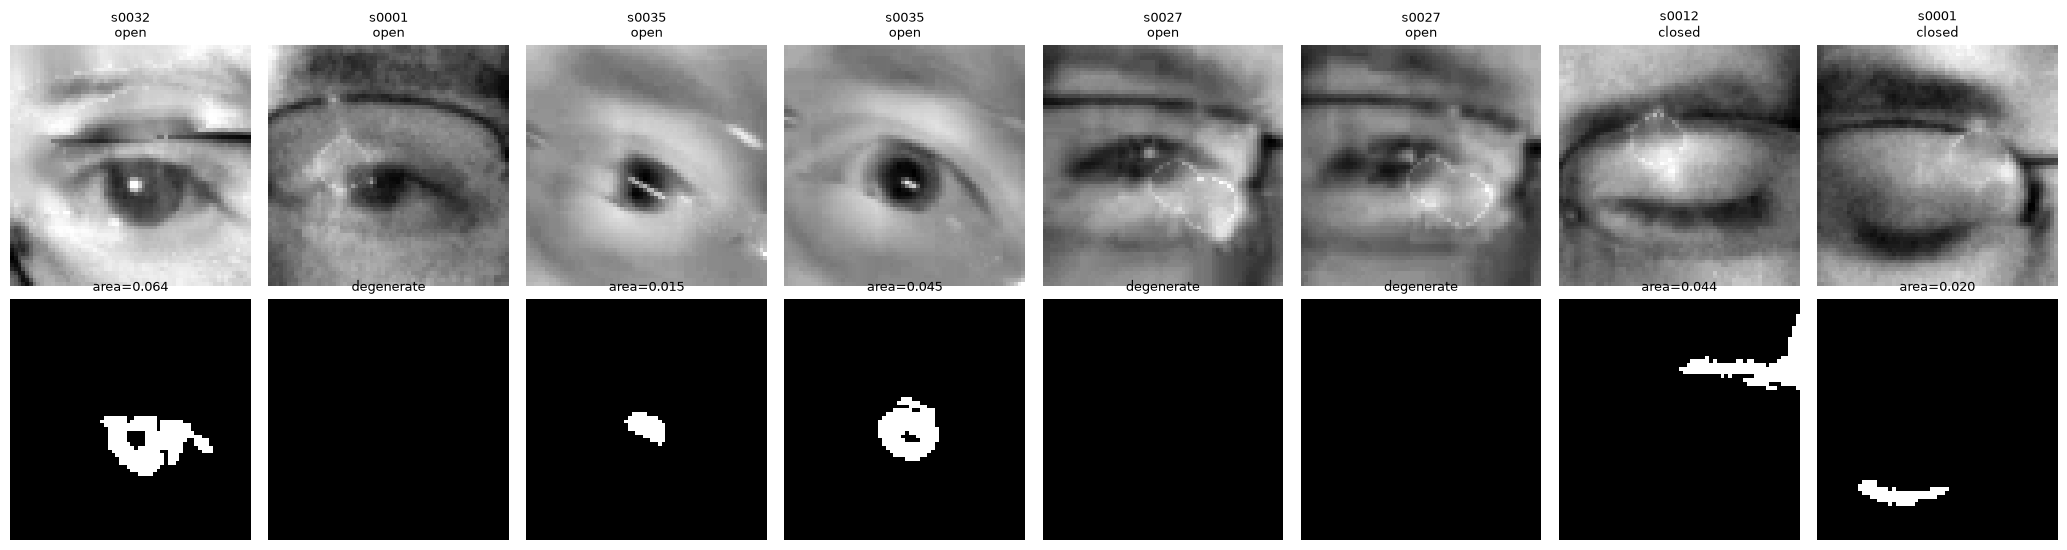

In [8]:
hard_samples = [s for s in samples if s.has_glasses and s.reflections == 2]
print(f"{len(hard_samples)} glasses=1 & reflections=2 samples")

n = len(hard_samples)
fig, axes = plt.subplots(2, n, figsize=(2.6 * n, 5.5))
for col, sample in enumerate(hard_samples):
    img = load_enhanced(sample)
    result = segment_eye(img, SegmentConfig())
    axes[0, col].imshow(img, cmap="gray")
    axes[0, col].set_title(f"{sample.subject_id}\n{'open' if sample.is_open else 'closed'}", fontsize=9)
    axes[1, col].imshow(result.region_mask, cmap="gray")
    axes[1, col].set_title("degenerate" if result.is_degenerate else f"area={result.dark_area_frac:.3f}", fontsize=9)
    for r in (0, 1):
        axes[r, col].axis("off")
axes[0, 0].set_ylabel("enhanced")
axes[1, 0].set_ylabel("region mask")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "week3_glasses_reflection_failures.png", dpi=120)
plt.show()

Honest read: some glare-affected crops still segment reasonably (Week 2's inpainting did
its job before thresholding ever ran), but others are visibly degraded — either the residual
specular ring interferes with the stricter pupil-anchored threshold, or the isolated region is
smaller/noisier than a glasses-free crop of the same eye state would produce. No claim of a
uniformly clean segmentation on this subset.

## Conclusion

- **Otsu** (global), threshold picked automatically per image, is the chosen default general
  segmentation method: ~5.8 mean connected components over the full working set vs. ~28
  (adaptive mean) and ~62 (adaptive Gaussian) at comparable speed — far less speckle for Week 4
  to clean.
- **Region isolation** anchors on `otsu_value * 0.7` (not the raw Otsu split, which is
  measurably non-discriminative between open/closed on this dataset) plus a largest-component +
  1%-area gate. This recovers a real but modest open/closed signal (naive same-signal accuracy
  ~0.58-0.59 over 6000 images) and, more importantly, an honest empty mask when no qualifying
  dark core is found.
- Feeds directly into Week 4 (`src/morphology.py`): `clean_mask()` refines
  `segment_eye(...).region_mask` before any shape feature is trusted.